In [4]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except Exception as e:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not available. The notebook will still work without the UI demo.")
    print("Error:", e)

np.random.seed(42)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def print_regression_metrics(y_true, y_pred, label="Model"):
    print(f"=== {label} ===")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", rmse(y_true, y_pred))
    print("R^2 :", r2_score(y_true, y_pred))

ipywidgets not available. The notebook will still work without the UI demo.
Error: No module named 'ipywidgets'


In [5]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Shape: (20640, 9)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


,missing_count
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


,corr_with_target
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


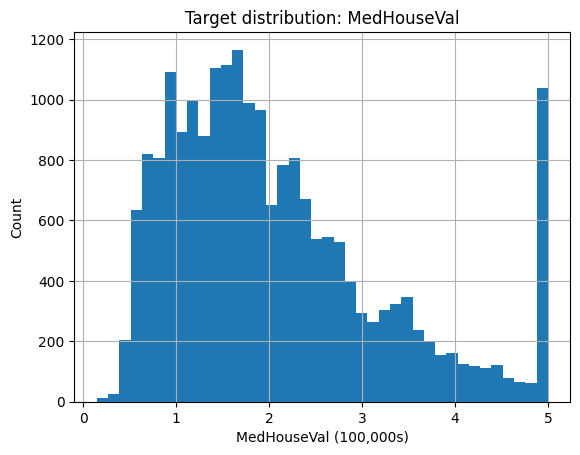

In [7]:
print("Shape:", df.shape)
display(df.describe().T)

display(df.isna().sum().to_frame("missing_count"))

corr = df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)
display(corr.to_frame("corr_with_target"))

plt.figure()
df["MedHouseVal"].hist(bins=40)
plt.title("Target distribution: MedHouseVal")
plt.xlabel("MedHouseVal (100,000s)")
plt.ylabel("Count")
plt.show()

In [8]:
target = "MedHouseVal"
X = df.drop(columns=[target])
y = df[target]

# Train+val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (12384, 8) Val: (4128, 8) Test: (4128, 8)


In [9]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ],
    remainder="drop"
)

preprocess

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [10]:
linreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

linreg_model.fit(X_train, y_train)
y_val_pred = linreg_model.predict(X_val)
print_regression_metrics(y_val, y_val_pred, label="Linear Regression (val)")

=== Linear Regression (val) ===
MAE : 0.5333346447415043
RMSE: 0.7278379693175869
R^2 : 0.6142000785497264


In [11]:
tree_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_reg.fit(X_train, y_train)
pred = tree_reg.predict(X_val)
print_regression_metrics(y_val, pred, label="DecisionTreeRegressor (val)")

=== DecisionTreeRegressor (val) ===
MAE : 0.45397695494186047
RMSE: 0.7057516421599788
R^2 : 0.6372591102014245


In [12]:
param_grid = {
    "model__max_depth": [2, 4, 6, 8, 12, None],
    "model__min_samples_leaf": [1, 5, 20, 50]
}

gs_tree = GridSearchCV(
    tree_reg,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gs_tree.fit(X_trainval, y_trainval)

print("Best params:", gs_tree.best_params_)
print("Best CV RMSE:", -gs_tree.best_score_)

Best params: {'model__max_depth': 12, 'model__min_samples_leaf': 20}
Best CV RMSE: 0.6060020485213207


In [13]:
rf_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg.fit(X_train, y_train)
pred = rf_reg.predict(X_val)
print_regression_metrics(y_val, pred, label="RandomForestRegressor (val)")

=== RandomForestRegressor (val) ===
MAE : 0.3334719494751296
RMSE: 0.5079717794389365
R^2 : 0.8120804817497702


In [14]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 5, 20],
    "model__max_features": ["sqrt", 1.0]
}

gs_rf = GridSearchCV(
    rf_reg,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

gs_rf.fit(X_trainval, y_trainval)

print("Best params:", gs_rf.best_params_)
print("Best CV RMSE:", -gs_rf.best_score_)

Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best CV RMSE: 0.5004055952380818


=== Best Regression Model (test) ===
MAE : 0.32592933731225815
RMSE: 0.492623341419997
R^2 : 0.8148076207188577


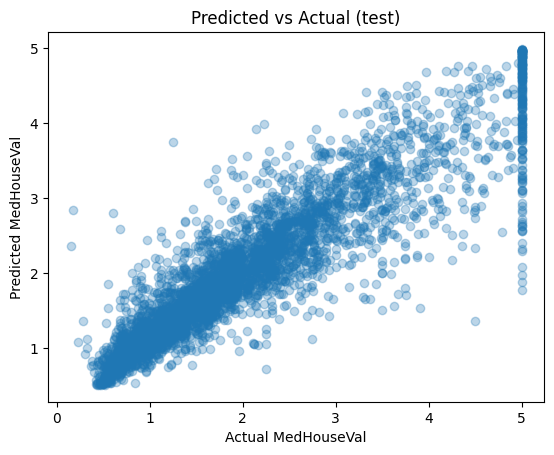

In [15]:
best_reg_model = gs_rf.best_estimator_ if "gs_rf" in globals() else rf_reg

best_reg_model.fit(X_trainval, y_trainval)
test_pred = best_reg_model.predict(X_test)

print_regression_metrics(y_test, test_pred, label="Best Regression Model (test)")

# Plot predicted vs actual
plt.figure()
plt.scatter(y_test, test_pred, alpha=0.3)
plt.title("Predicted vs Actual (test)")
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.show()

,feature,importance
0,MedInc,0.360118
6,Latitude,0.133270
7,Longitude,0.129611
5,AveOccup,0.123105
2,AveRooms,0.117104
1,HouseAge,0.056579
3,AveBedrms,0.044675
4,Population,0.035538


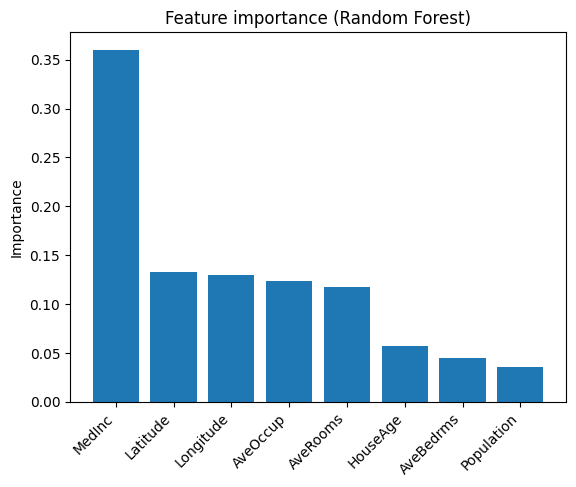

In [16]:
reg_est = best_reg_model.named_steps["model"]
if hasattr(reg_est, "feature_importances_"):
    importances = reg_est.feature_importances_
    fi = pd.DataFrame({
        "feature": numeric_features,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(fi)

    plt.figure()
    plt.bar(fi["feature"], fi["importance"])
    plt.title("Feature importance (Random Forest)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.show()
else:
    print("Feature importance not available for this model type.")

In [17]:
threshold = y_trainval.median()
print("HighPrice threshold (median):", float(threshold))

y_bin = (y >= threshold).astype(int)

X_trainval_c, X_test_c, y_trainval_c, y_test_c = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_trainval_c, y_trainval_c, test_size=0.25, random_state=42, stratify=y_trainval_c
)

print("Class balance (train):", np.bincount(y_train_c) / len(y_train_c))

HighPrice threshold (median): 1.7985
Class balance (train): [0.50064599 0.49935401]


In [18]:
def eval_classifier(model, Xv, yv, label="Model"):
    pred = model.predict(Xv)
    proba = model.predict_proba(Xv)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"=== {label} ===")
    print("Accuracy :", accuracy_score(yv, pred))
    print("Precision:", precision_score(yv, pred))
    print("Recall   :", recall_score(yv, pred))
    print("F1       :", f1_score(yv, pred))
    if proba is not None:
        print("ROC-AUC  :", roc_auc_score(yv, proba))
    print()
    print("Confusion matrix:" , confusion_matrix(yv, pred))
    print()
    print(classification_report(yv, pred))

# Logistic Regression
log_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

log_clf.fit(X_train_c, y_train_c)
eval_classifier(log_clf, X_val_c, y_val_c, label="Logistic Regression (val)")

# Decision Tree
dt_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_clf.fit(X_train_c, y_train_c)
eval_classifier(dt_clf, X_val_c, y_val_c, label="Decision Tree Classifier (val)")

# Random Forest
rf_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train_c, y_train_c)
eval_classifier(rf_clf, X_val_c, y_val_c, label="Random Forest Classifier (val)")

=== Logistic Regression (val) ===
Accuracy : 0.8386627906976745
Precision: 0.8361445783132531
Recall   : 0.8418243571081999
F1       : 0.8389748549323017
ROC-AUC  : 0.9150756780319276

Confusion matrix: [[1727  340]
 [ 326 1735]]

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      2067
           1       0.84      0.84      0.84      2061

    accuracy                           0.84      4128
   macro avg       0.84      0.84      0.84      4128
weighted avg       0.84      0.84      0.84      4128

=== Decision Tree Classifier (val) ===
Accuracy : 0.8374515503875969
Precision: 0.8351012536162006
Recall   : 0.8403687530325085
F1       : 0.837726723095526
ROC-AUC  : 0.8374557843536998

Confusion matrix: [[1725  342]
 [ 329 1732]]

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      2067
           1       0.84      0.84      0.84      2061

    accuracy                           0.84

Test ROC-AUC: 0.9642149326997312


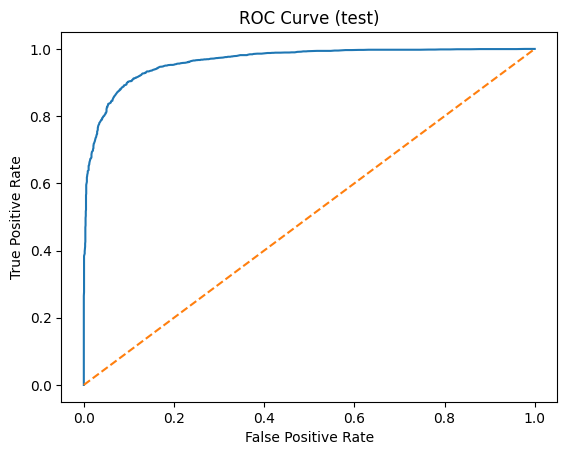

In [ ]:
best_clf = rf_clf

best_clf.fit(X_trainval_c, y_trainval_c)
proba = best_clf.predict_proba(X_test_c)[:, 1]
pred = best_clf.predict(X_test_c)

print("Test ROC-AUC:", roc_auc_score(y_test_c, proba))

fpr, tpr, _ = roc_curve(y_test_c, proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve (test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

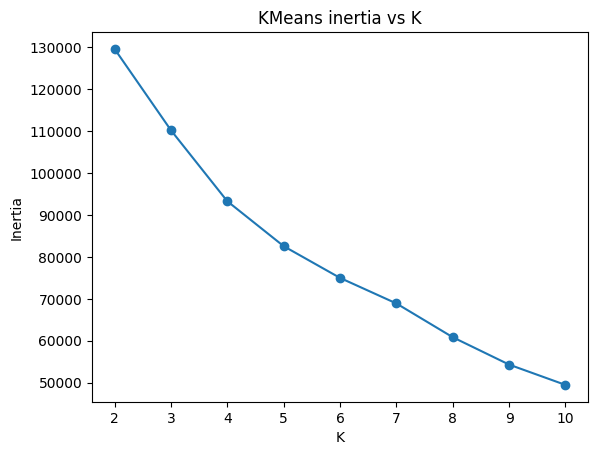

In [20]:
X_scaled = numeric_transformer.fit_transform(X)

inertias = []
ks = list(range(2, 11))

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(ks, inertias, marker="o")
plt.title("KMeans inertia vs K")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()


In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster = df.copy()
df_cluster["Cluster"] = clusters
df_cluster[["Cluster"]].value_counts().sort_index()

Cluster
0          8214
1          3920
2          8429
3             3
4            74
Name: count, dtype: int64

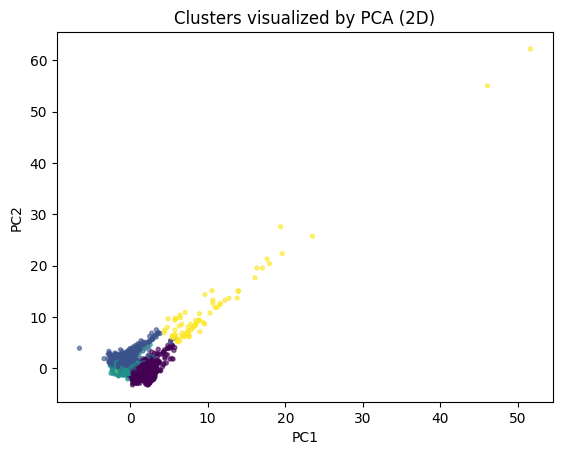

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
Cluster,,,,,,,,,
0,3.736760,29.348430,5.467913,1.082817,1223.972608,2.776631,37.995739,-121.780409,1.969782
1,5.623366,17.360969,6.381841,1.092945,2222.636224,3.089592,34.127515,-118.145839,2.612306
2,3.189387,33.276308,4.711695,1.062026,1259.510618,3.076230,34.008387,-118.078197,1.915851
3,6.669400,42.333333,5.795482,1.094628,6063.333333,781.836386,38.016667,-121.063333,1.850000
4,3.377838,18.689189,32.324874,6.779343,280.945946,2.497513,37.757027,-119.438108,1.631838


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=8, alpha=0.6)
plt.title("Clusters visualized by PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

profile = df_cluster.groupby("Cluster")[numeric_features + ["MedHouseVal"]].mean()
display(profile)

In [ ]:
if not WIDGETS_AVAILABLE:
    print("Widgets are not available in this environment. Skipping UI demo.")
else:
    best_reg_model.fit(X_trainval, y_trainval)

    medians = X_trainval.median()

    sliders = {}
    for col in numeric_features:
        col_min = float(X[col].quantile(0.01))
        col_max = float(X[col].quantile(0.99))
        col_val = float(medians[col])
        step = (col_max - col_min) / 200 if (col_max - col_min) > 0 else 0.01
        sliders[col] = widgets.FloatSlider(
            value=col_val, min=col_min, max=col_max, step=step,
            description=col, continuous_update=False, readout_format=".3f",
            layout=widgets.Layout(width="95%")
        )

    predict_btn = widgets.Button(description="Predict price", button_style="success")
    out = widgets.Output()

    def do_predict(_):
        with out:
            clear_output()
            row = {c: sliders[c].value for c in numeric_features}
            x_in = pd.DataFrame([row])
            pred = float(best_reg_model.predict(x_in)[0])
            print(f"Predicted MedHouseVal: {pred:.3f} (≈ ${pred*100000:,.0f})")

    predict_btn.on_click(do_predict)

    display(widgets.VBox([
        widgets.HTML("Interactive House Price Prediction"),
        widgets.VBox(list(sliders.values())),
        predict_btn,
        out
    ]))

Widgets are not available in this environment. Skipping UI demo.


In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

clf_model = None
for candidate in ['best_clf_model', 'best_clf', 'clf_model', 'rf_clf', 'best_xgb_clf', 'model_clf']:
    if candidate in globals():
        clf_model = globals()[candidate]
        break

y_target_clf = None
if 'y_test_clf' in globals():
    y_target_clf = y_test_clf
elif 'y_test' in globals() and 'y_trainval' in globals():
    y_target_clf = (y_test >= y_trainval.median()).astype(int)

if clf_model is None and 'val_results_clf' in globals():
    print("\n[2] CLASSIFICATION LEADERBOARD (Validation):")
    display(pd.DataFrame(val_results_clf).T)
elif clf_model is not None and y_target_clf is not None:
    y_clf_pred = clf_model.predict(X_test)
    y_clf_prob = clf_model.predict_proba(X_test)[:, 1] if hasattr(clf_model, "predict_proba") else None

    acc = accuracy_score(y_target_clf, y_clf_pred)
    prec = precision_score(y_target_clf, y_clf_pred, zero_division=0)
    rec = recall_score(y_target_clf, y_clf_pred, zero_division=0)
    f1 = f1_score(y_target_clf, y_clf_pred, zero_division=0)
    roc = roc_auc_score(y_target_clf, y_clf_prob) if y_clf_prob is not None else float("nan")

    print("\n[2] CLASSIFICATION METRICS (Test Set):")
    print(f"  - Accuracy:   {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  - F1-Score:   {f1:.4f}")
    print(f"  - Precision:  {prec:.4f}")
    print(f"  - Recall:     {rec:.4f}")
    print(f"  - ROC-AUC:    {roc:.4f}")
else:
    print("\n[2] Classification: Model or test labels not found in environment.")



[2] CLASSIFICATION METRICS (Test Set):
  - Accuracy:   0.9801  (98.01%)
  - F1-Score:   0.9800
  - Precision:  0.9819
  - Recall:     0.9780
  - ROC-AUC:    0.9968


In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import silhouette_score

print("=" * 60)
print("              QUICK ACCURACY & METRICS DASHBOARD")
print("=" * 60)

try:
    y_reg_pred = best_reg_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_reg_pred))
    mae = mean_absolute_error(y_test, y_reg_pred)
    r2 = r2_score(y_test, y_reg_pred)

    print("\n[1] REGRESSION METRICS (Test Set):")
    print(f"  - R² Score:   {r2:.4f}  ({r2*100:.2f}%)")
    print(f"  - RMSE: {rmse:.4f}  (≈ ${rmse*100000:,.0f})")
    print(f"  - MAE:  {mae:.4f}  (≈ ${mae*100000:,.0f})")
except Exception as e:
    print(f"\n[1] Regression Error: {e}")

clf_model = None
for candidate in ['best_clf_model', 'best_clf', 'clf_model', 'rf_clf', 'best_xgb_clf', 'model_clf']:
    if candidate in globals():
        clf_model = globals()[candidate]
        break

y_target_clf = None
for candidate_y in ['y_test_clf', 'y_test_binary', 'y_test_class', 'y_clf_test']:
    if candidate_y in globals():
        y_target_clf = globals()[candidate_y]
        break

if y_target_clf is None and 'y_test' in globals() and 'threshold' in globals():
    y_target_clf = (y_test >= threshold).astype(int)
elif y_target_clf is None and 'y_test' in globals() and 'y_trainval' in globals():
    y_target_clf = (y_test >= y_trainval.median()).astype(int)

try:
    if clf_model is not None and y_target_clf is not None:
        y_clf_pred = clf_model.predict(X_test)
        y_clf_prob = clf_model.predict_proba(X_test)[:, 1] if hasattr(clf_model, "predict_proba") else None

        acc = accuracy_score(y_target_clf, y_clf_pred)
        prec = precision_score(y_target_clf, y_clf_pred, zero_division=0)
        rec = recall_score(y_target_clf, y_clf_pred, zero_division=0)
        f1 = f1_score(y_target_clf, y_clf_pred, zero_division=0)
        roc = roc_auc_score(y_target_clf, y_clf_prob) if y_clf_prob is not None else float("nan")

        print("\n[2] CLASSIFICATION METRICS (Test Set):")
        print(f"  - Accuracy:         {acc:.4f}  ({acc*100:.2f}%)")
        print(f"  - F1-Score: {f1:.4f}")
        print(f"  - Precision:           {prec:.4f}")
        print(f"  - Recall:           {rec:.4f}")
        print(f"  - ROC-AUC:                   {roc:.4f}")
    elif 'val_results_clf' in globals():
        print("\n[2] CLASSIFICATION LEADERBOARD (Validation):")
        display(pd.DataFrame(val_results_clf).T)
    else:
        print("\n[2] Classification: مدل یا داده تست دسته‌بندی در دسترس نیست.")
except Exception as e:
    print(f"\n[2] Classification Error: {e}")

try:
    sil = silhouette_score(X_scaled, clusters, sample_size=3000, random_state=42)
    print("\n[3] CLUSTERING METRICS (K-Means):")
    print(f"  - Inertia: {kmeans.inertia_:.2f}")
    print(f"  - Silhouette Score:          {sil:.4f}")
except Exception as e:
    print(f"\n[3] Clustering Error: {e}")

print("=" * 60)


              QUICK ACCURACY & METRICS DASHBOARD

[1] REGRESSION METRICS (Test Set):
  - R² Score:   0.8148  (81.48%)
  - RMSE: 0.4926  (≈ $49,262)
  - MAE:  0.3259  (≈ $32,593)

[2] CLASSIFICATION METRICS (Test Set):
  - Accuracy:         0.9801  (98.01%)
  - F1-Score: 0.9800
  - Precision:           0.9819
  - Recall:           0.9780
  - ROC-AUC:                   0.9968

[3] CLUSTERING METRICS (K-Means):
  - Inertia: 82558.81
  - Silhouette Score:          0.2973
